# PyTorch Learning Notebook

A first pass at PyTorch fundamentals: tensors, autograd, and a basic training loop.
The end-to-end example uses a toy regression problem (predicting a return-like target from a few features) since that maps onto the kind of data you already work with.

## 0. Check the install

In [1]:
import torch
import torch.nn as nn

print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())  # False is expected on cpuonly builds

torch version: 2.11.0
CUDA available: False


## 1. Tensors

Tensors are PyTorch's array type — like numpy arrays, but they can track gradients and run on GPU. Think of them as the pandas DataFrame/numpy array equivalent for this ecosystem.

In [2]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.ones(3)
print(x + y)
print(x * y)
print(x.shape, x.dtype)

tensor([2., 3., 4.])
tensor([1., 2., 3.])
torch.Size([3]) torch.float32


In [3]:
import numpy as np

# numpy <-> tensor conversion, common when mixing with pandas/numpy pipelines
arr = np.random.randn(4, 3)
t = torch.from_numpy(arr).float()
print(t)
print(t.numpy())

tensor([[ 0.3510, -1.0559,  0.2621],
        [ 1.2582, -0.2573, -0.8761],
        [-1.2747, -0.4703,  0.0184],
        [-0.4463,  0.4812,  2.3030]])
[[ 0.35096654 -1.0558548   0.26206303]
 [ 1.2582022  -0.2573152  -0.87607837]
 [-1.2746801  -0.47026837  0.01844642]
 [-0.446297    0.48117155  2.3030102 ]]


## 1b. Tensor ops: reshape, matmul, broadcasting

These three show up in almost every model you'll write, so worth being deliberate about them.

- **reshape/view**: change how a tensor's data is sliced into dimensions without copying or changing values.
- **matmul (`@`)**: real matrix multiplication (contracts a shared dimension) — different from `*`, which is elementwise.
- **broadcasting**: lets ops work on mismatched shapes by implicitly expanding size-1 dimensions, e.g. normalizing every row by a per-column stat without writing a loop.

In [9]:
# reshape / view: same 12 numbers, different "shapes" onto that data
returns = torch.arange(12.0)  # pretend: 3 assets x 4 days, flattened
print(returns)

by_asset = returns.reshape(3, 4)   # 3 assets, 4 days each
print(by_asset)

by_day = returns.reshape(4, 3)     # 4 days, 3 assets each
print(by_day)

# -1 means "infer this dimension"
print(returns.reshape(3, -1).shape)

# view requires contiguous memory; reshape works either way (copies if needed)
print(by_asset.t().is_contiguous())   # False after transpose
print(by_asset.t().reshape(-1))       # reshape still works (copies under the hood)

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])
torch.Size([3, 4])
False
tensor([ 0.,  4.,  8.,  1.,  5.,  9.,  2.,  6., 10.,  3.,  7., 11.])


In [10]:
# matmul vs elementwise multiply
weights = torch.tensor([0.5, 0.3, 0.2])   # portfolio weights, 3 assets
asset_returns = by_asset                  # (3 assets, 4 days), from the cell above

# matmul contracts the shared dimension (3 assets) -> portfolio return per day
portfolio_returns = weights @ asset_returns   # (3,) @ (3,4) -> (4,)
print("portfolio returns per day:", portfolio_returns)

# elementwise * requires matching (or broadcastable) shapes -- this is NOT matmul
# weights * asset_returns would error: (3,) vs (3,4) don't broadcast against each other directly

# batch matmul: e.g. covariance-style projection for a batch of scenarios
batch = torch.randn(8, 3, 4)              # 8 scenarios, 3 assets, 4 days
batch_portfolio = weights @ batch         # broadcasts weights over the batch dim
print(batch_portfolio.shape)              # (8, 4)

portfolio returns per day: tensor([2.8000, 3.8000, 4.8000, 5.8000])
torch.Size([8, 4])


In [12]:
# broadcasting: align shapes from the right; size-1 dims expand to match
prices = torch.tensor([[100.0, 200.0, 50.0],
                        [101.0, 198.0, 51.0],
                        [99.0,  202.0, 49.0]])   # (3 days, 3 assets)

day_one_prices = prices[0]              # shape (3,)  -- one value per asset
normalized = prices / day_one_prices    # (3,3) / (3,) -> broadcasts over rows
print(normalized)                       # each column now indexed to its day-0 price

# the rule: compare shapes from the trailing dim; each dim must match, or be 1, or be missing
col_mean = prices.mean(dim=0)           # shape (3,) -- mean price per asset
print(col_mean.shape, (prices - col_mean).shape)  # broadcasts fine: (3,3) - (3,)

row_mean = prices.mean(dim=1)           # shape (3,) -- mean price per day
# prices - row_mean would broadcast WRONG (matches against asset dim, not day dim)
# fix: make it explicitly a column vector so it aligns with the day dimension
print((prices - row_mean.unsqueeze(1)).shape)     # (3,3) - (3,1) -> (3,3), correctly per-row

tensor([[1.0000, 1.0000, 1.0000],
        [1.0100, 0.9900, 1.0200],
        [0.9900, 1.0100, 0.9800]])
torch.Size([3]) torch.Size([3, 3])
torch.Size([3, 3])


## 2. Autograd

Set `requires_grad=True` and PyTorch records the operations on a tensor so it can compute gradients automatically via `.backward()`. This is what makes gradient descent on a custom model possible without deriving the gradient by hand.

In [4]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

x = torch.tensor(3.0)
y = w * x + b          # y = 2*3 + 1 = 7
loss = (y - 10) ** 2    # squared error against a target of 10

loss.backward()
print("loss:", loss.item())
print("dloss/dw:", w.grad.item())
print("dloss/db:", b.grad.item())

loss: 9.0
dloss/dw: -18.0
dloss/db: -6.0


## 3. A toy dataset

Synthetic data: target is a noisy linear combination of a few features, similar in spirit to a factor-model setup. The point here is the PyTorch mechanics, not the modeling realism.

In [5]:
torch.manual_seed(0)

n_samples, n_features = 500, 4
X = torch.randn(n_samples, n_features)

true_weights = torch.tensor([0.5, -0.3, 0.8, 0.1])
true_bias = 0.05
noise = 0.1 * torch.randn(n_samples)

y = X @ true_weights + true_bias + noise
y = y.unsqueeze(1)  # shape (n_samples, 1) to match model output

print(X.shape, y.shape)

torch.Size([500, 4]) torch.Size([500, 1])


## 4. Define a model

`nn.Module` is the base class for any model. Here a single linear layer — equivalent to OLS, just fit by gradient descent instead of a closed-form solution.

In [6]:
class LinearRegressor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressor(n_features)
print(model)
print("initial weights:", model.linear.weight.data)

LinearRegressor(
  (linear): Linear(in_features=4, out_features=1, bias=True)
)
initial weights: tensor([[ 0.0992, -0.4218,  0.0831, -0.2685]])


## 5. Training loop

The standard pattern: forward pass → compute loss → zero old gradients → backward pass → optimizer step. Every PyTorch training loop, no matter how complex the model, is a variation of this.

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

n_epochs = 200
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    preds = model(X)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}")

print("\nlearned weights:", model.linear.weight.data)
print("true weights:    ", true_weights)
print("learned bias:", model.linear.bias.item(), " true bias:", true_bias)

epoch   0  loss 0.8733
epoch  20  loss 0.0092
epoch  40  loss 0.0091
epoch  60  loss 0.0091
epoch  80  loss 0.0091
epoch 100  loss 0.0091
epoch 120  loss 0.0091
epoch 140  loss 0.0091
epoch 160  loss 0.0091
epoch 180  loss 0.0091

learned weights: tensor([[ 0.4947, -0.3038,  0.8069,  0.0997]])
true weights:     tensor([ 0.5000, -0.3000,  0.8000,  0.1000])
learned bias: 0.046585142612457275  true bias: 0.05


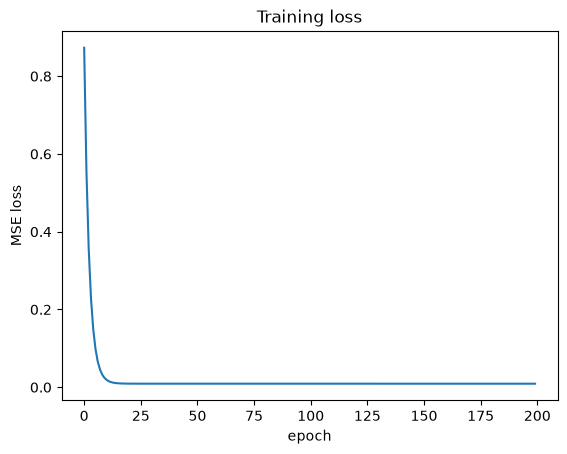

In [8]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.show()

## 6. Next steps

- Swap `LinearRegressor` for a small MLP (`nn.Sequential` with `nn.ReLU` between linear layers) and see how it does on nonlinear targets.
- Use `torch.utils.data.DataLoader` for mini-batches instead of feeding the full dataset each step.
- Try `Adam` instead of `SGD` as the optimizer.
- Once comfortable, point the same pipeline at real features (e.g. lagged returns, spreads, ratings) instead of synthetic data.